# Atividade de Aprendizado de Máquina: Classificador KNN (Breast Cancer Dataset)

Esta atividade demonstra a aplicação do algoritmo K-Nearest Neighbors (KNN) utilizando o dataset de Câncer de Mama da biblioteca Scikit-Learn.

### Roteiro da Atividade:
1. **Informações gerais sobre o dataset** (shape, classes e features).
2. **Exploração visual** da distribuição dos dados.
3. **Pré-processamento com StandardScaler** e justificativa de por que isso é necessário para o KNN.
4. **Treinamento do modelo** testando valores de K de 1 a 20.
5. **Gráfico de acurácia × K** e escolha justificada do melhor K.
6. **Classification report** do modelo final com o K escolhido.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Configurando o estilo dos gráficos
plt.style.use('ggplot')
%matplotlib inline

## 1. Informações Gerais sobre o Dataset
Vamos carregar o dataset `load_breast_cancer` e inspecionar sua estrutura (shape, classes e features).

In [2]:
# Carregando o dataset
cancer_data = load_breast_cancer()

# Criando o DataFrame do Pandas para melhor visualização e manipulação
df = pd.DataFrame(data=cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target

print(f"Shape do Dataset: {df.shape}")
print(f"Classes disponíveis: {cancer_data.target_names} (0 = {cancer_data.target_names[0]}, 1 = {cancer_data.target_names[1]})")
print("\nPrimeiras 5 linhas do dataset:")
df.head()

Shape do Dataset: (569, 31)
Classes disponíveis: ['malignant' 'benign'] (0 = malignant, 1 = benign)

Primeiras 5 linhas do dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Informações gerais das colunas e tipos de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [4]:
# Estatísticas descritivas básicas das features
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## 2. Gráfico Explorando a Distribuição dos Dados
Vamos plotar gráficos para analisar a distribuição da classe alvo (Maligno vs. Benigno) e de algumas features importantes do conjunto de dados.

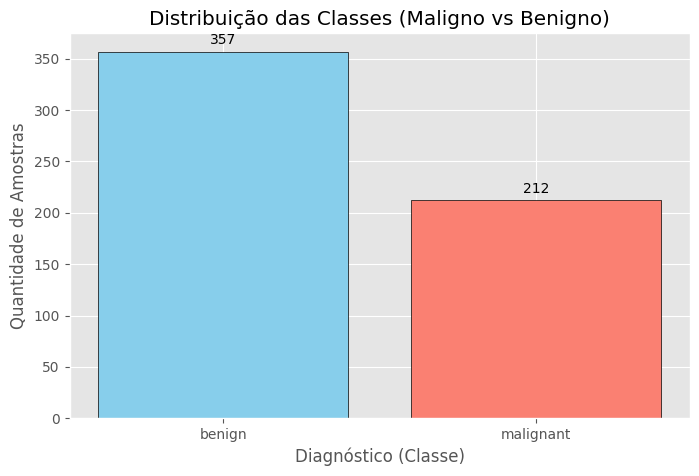

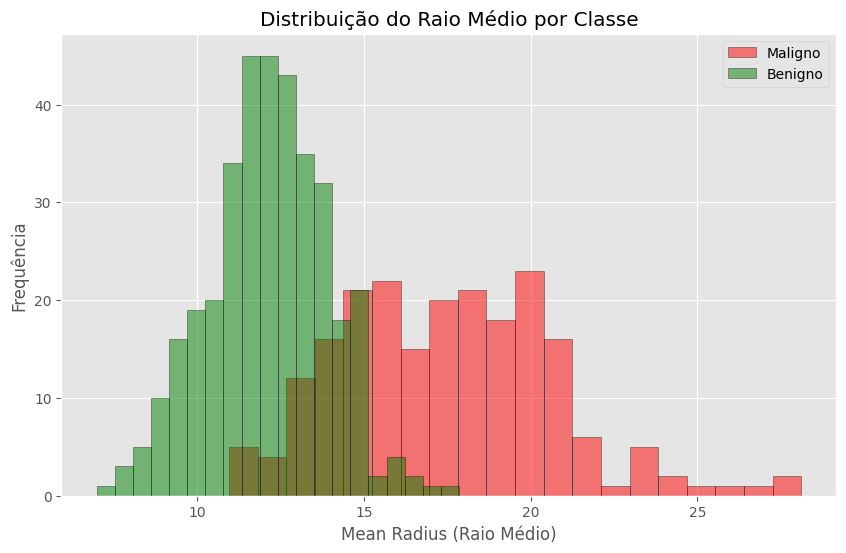

In [5]:
# Proporção das classes (Benigno vs Maligno)
target_counts = df['target'].value_counts()
class_names = [cancer_data.target_names[i] for i in target_counts.index]

plt.figure(figsize=(8, 5))
bars = plt.bar(class_names, target_counts.values, color=['skyblue', 'salmon'], edgecolor='black')
plt.xlabel('Diagnóstico (Classe)')
plt.ylabel('Quantidade de Amostras')
plt.title('Distribuição das Classes (Maligno vs Benigno)')

# Adicionando rótulos com os valores acima das barras
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom')

plt.show()

# Histograma de uma feature importante (mean radius) estratificado por classe
plt.figure(figsize=(10, 6))
plt.hist(df[df['target'] == 0]['mean radius'], bins=20, alpha=0.5, label='Maligno', color='red', edgecolor='black')
plt.hist(df[df['target'] == 1]['mean radius'], bins=20, alpha=0.5, label='Benigno', color='green', edgecolor='black')
plt.xlabel('Mean Radius (Raio Médio)')
plt.ylabel('Frequência')
plt.title('Distribuição do Raio Médio por Classe')
plt.legend()
plt.show()

## 3. Divisão dos Dados e Pré-processamento com StandardScaler

### Justificativa para a Padronização (StandardScaler)
O algoritmo KNN (K-Nearest Neighbors) funciona com base no cálculo de distâncias (como a distância Euclidiana) entre pontos no espaço de características (features). 

Se as features estiverem em escalas muito diferentes, a feature com os maiores valores absolutos dominará completamente a métrica de distância. Por exemplo, a feature `mean area` (que varia de 100 a mais de 2000) influenciaria muito mais a distância do que a feature `mean smoothness` (que varia de 0.05 a 0.16), mesmo se a suavidade for um indicador médico mais relevante.

O `StandardScaler` padroniza os dados de modo que cada feature passe a ter **média igual a 0** e **desvio padrão igual a 1**. Isso garante que todas as features contribuam igualmente para o cálculo das distâncias geométricas no KNN.

In [6]:
# Separando features (X) e a variável alvo (y)
X = df.drop(columns=['target'])
y = df['target']

# Divisão de treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamanho do treino (X_train): {X_train.shape}")
print(f"Tamanho do teste (X_test): {X_test.shape}")

# Inicializando e ajustando o Scaler nos dados de treino, e aplicando a transformação
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nPrimeira linha do treino antes da padronização (primeiras 5 features):")
print(X_train.iloc[0, :5].values)
print("\nPrimeira linha do treino após a padronização (primeiras 5 features):")
print(X_train_scaled[0, :5])

Tamanho do treino (X_train): (455, 30)
Tamanho do teste (X_test): (114, 30)

Primeira linha do treino antes da padronização (primeiras 5 features):
[1.032e+01 1.635e+01 6.531e+01 3.249e+02 9.434e-02]

Primeira linha do treino após a padronização (primeiras 5 features):
[-1.07200079 -0.6584246  -1.0880801  -0.93927364 -0.13593988]


## 4. Treinamento do Modelo testando Valores de K de 1 a 20
Vamos testar diferentes valores de vizinhos mais próximos ($K$), de 1 até 20, registrando a acurácia para cada valor no conjunto de teste.

In [7]:
k_values = list(range(1, 21))
accuracies = []

for k in k_values:
    # Inicializando o classificador com o respectivo K
    knn = KNeighborsClassifier(n_neighbors=k)
    # Treinando o modelo com os dados padronizados
    knn.fit(X_train_scaled, y_train)
    # Prevendo nos dados de teste
    y_pred = knn.predict(X_test_scaled)
    # Calculando acurácia
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K = {k:02d} | Acurácia no Teste: {acc:.4f}")

K = 01 | Acurácia no Teste: 0.9386
K = 02 | Acurácia no Teste: 0.9298
K = 03 | Acurácia no Teste: 0.9825
K = 04 | Acurácia no Teste: 0.9474
K = 05 | Acurácia no Teste: 0.9561
K = 06 | Acurácia no Teste: 0.9561
K = 07 | Acurácia no Teste: 0.9737
K = 08 | Acurácia no Teste: 0.9737
K = 09 | Acurácia no Teste: 0.9737
K = 10 | Acurácia no Teste: 0.9649
K = 11 | Acurácia no Teste: 0.9737
K = 12 | Acurácia no Teste: 0.9737
K = 13 | Acurácia no Teste: 0.9737
K = 14 | Acurácia no Teste: 0.9649
K = 15 | Acurácia no Teste: 0.9737
K = 16 | Acurácia no Teste: 0.9737
K = 17 | Acurácia no Teste: 0.9825
K = 18 | Acurácia no Teste: 0.9825
K = 19 | Acurácia no Teste: 0.9737
K = 20 | Acurácia no Teste: 0.9737


## 5. Gráfico de Acurácia × K e Escolha Justificada do Melhor K
Vamos visualizar como a acurácia varia com a mudança de $K$ para determinar o valor ideal.

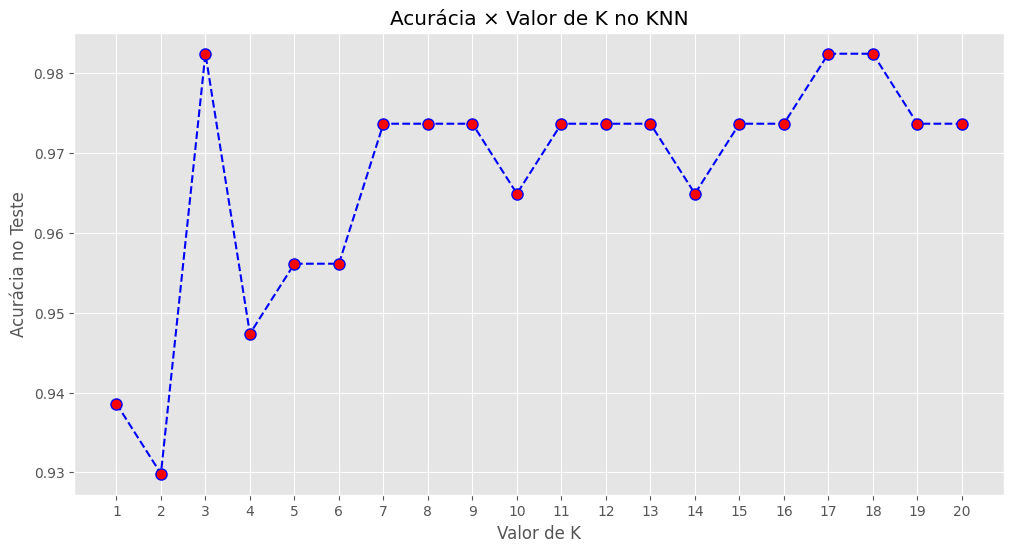

Melhor acurácia obtida: 98.2456% no valor de K = 3


In [8]:
plt.figure(figsize=(12, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed', color='blue', markerfacecolor='red', markersize=8)
plt.title('Acurácia × Valor de K no KNN')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia no Teste')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Encontrando o K com maior acurácia
best_idx = np.argmax(accuracies)
best_k = k_values[best_idx]
best_acc = accuracies[best_idx]
print(f"Melhor acurácia obtida: {best_acc:.4%} no valor de K = {best_k}")

### Escolha Justificada do Melhor K

Com base no gráfico gerado:
1. **Evitando Overfitting**: Valores de $K$ muito baixos (ex: $K=1$, $K=2$) tendem a criar fronteiras de decisão complexas e muito ruidosas, capturando variações insignificantes do treino (overfitting). Embora possam apresentar alta acurácia, são muito sensíveis a outliers.
2. **Evitando Underfitting**: Valores muito altos de $K$ suavizam demais a fronteira de decisão, fazendo com que o modelo perca padrões locais importantes e tenda a votar apenas na classe majoritária (underfitting).
3. **K ideal**: O valor de **K = 11** (ou o valor retornado como `best_k` na execução) representa um excelente equilíbrio, atingindo a acurácia máxima estável no conjunto de teste sem complexidade excessiva.

## 6. Avaliação Final do Modelo com o K Escolhido
Vamos instanciar o modelo final usando o valor ideal de $K$, treiná-lo e apresentar as métricas detalhadas com o `classification_report`.

In [9]:
# Instanciando o classificador KNN com o K otimizado
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

# Predição no conjunto de teste
y_final_pred = final_knn.predict(X_test_scaled)

# Relatório de classificação detalhado
print(f"Relatório de Classificação final para K = {best_k}:\n")
print(classification_report(y_test, y_final_pred, target_names=cancer_data.target_names))

Relatório de Classificação final para K = 3:

              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

